In [27]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import gaussian_kde
from scipy.integrate import quad
from tqdm import tqdm
plt.style.use(['science','no-latex'])

colors = ["#1982c4", "black", "#ff595e", "#20b806"]

Read data

In [3]:
seeds = np.arange(4)
ntrajs = 2500
nsteps = 1000
traj_noint = np.zeros((nsteps,len(seeds),ntrajs,2))
traj_intx0 =  np.zeros((nsteps,len(seeds),ntrajs,2))
traj_intx5 =  np.zeros((nsteps,len(seeds),ntrajs,2))
traj_intx12 = np.zeros((nsteps,len(seeds),ntrajs,2))
traj_inty0 =  np.zeros((nsteps,len(seeds),ntrajs,2))
traj_inty5 =  np.zeros((nsteps,len(seeds),ntrajs,2))
traj_inty12 =  np.zeros((nsteps,len(seeds),ntrajs,2))
dir_noint = "/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far_int/pickles_traj"
dirx = "/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far_int/pickles_traj_intx"
diry = "/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far_int/pickles_traj_inty"
for seed in seeds:
    with open(f"{dir_noint}/seed{seed}_N2500_dt0.01_samplingdt1000_nsteps1000000_frict1_temp1.p","rb") as f:
        traj_noint[:,seed] = (
            pickle.load(f)
        )
    with open(f"{dirx}/seed{seed}_N2500_dt0.01_samplingdt1000_nsteps1000000_frict1_temp1.p","rb") as f:
        [traj_intx0[:,seed], traj_intx5[:,seed], traj_intx12[:,seed]] = (
            pickle.load(f)
        )
    with open(f"{diry}/seed{seed}_N2500_dt0.01_samplingdt1000_nsteps1000000_frict1_temp1.p","rb") as f:
        [traj_inty0[:,seed], traj_inty5[:,seed], traj_inty12[:,seed]] = (
            pickle.load(f)
        )

traj_noint = traj_noint.reshape((nsteps,len(seeds)*ntrajs,2))
traj_intx0 = traj_intx0.reshape((nsteps,len(seeds)*ntrajs,2))
traj_intx5 = traj_intx5.reshape((nsteps,len(seeds)*ntrajs,2))
traj_intx12 = traj_intx12.reshape((nsteps,len(seeds)*ntrajs,2))
traj_inty0 = traj_inty0.reshape((nsteps,len(seeds)*ntrajs,2))
traj_inty5 = traj_inty5.reshape((nsteps,len(seeds)*ntrajs,2))
traj_inty12 = traj_inty12.reshape((nsteps,len(seeds)*ntrajs,2))

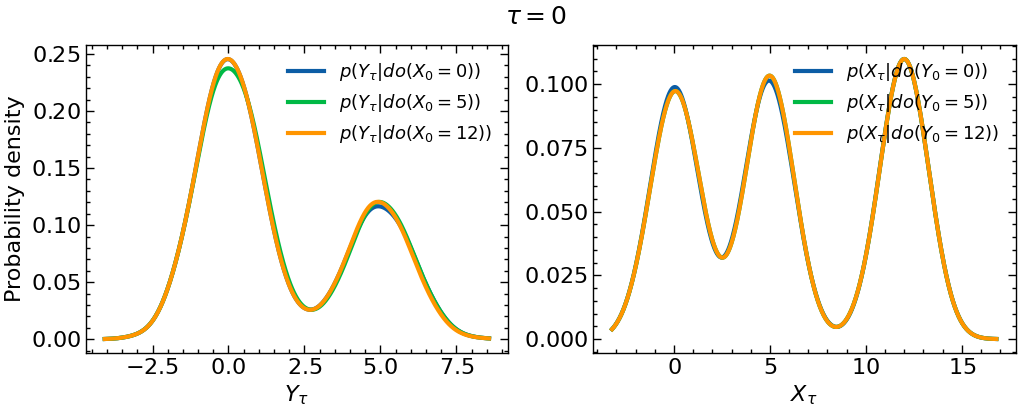

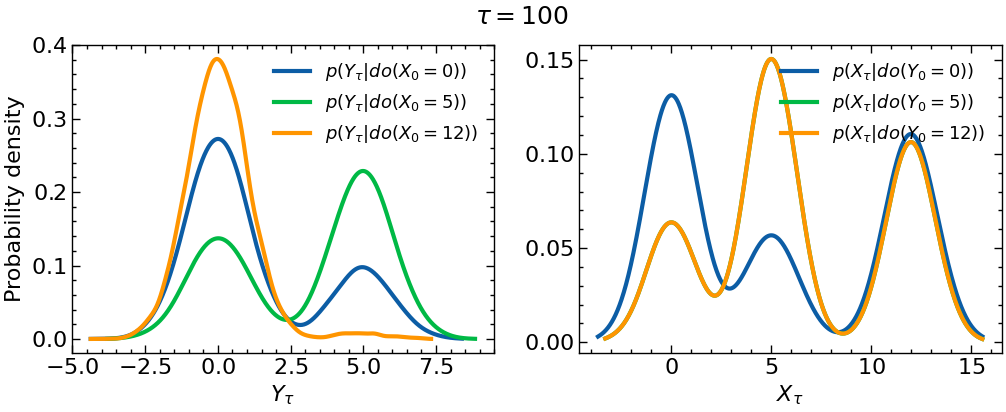

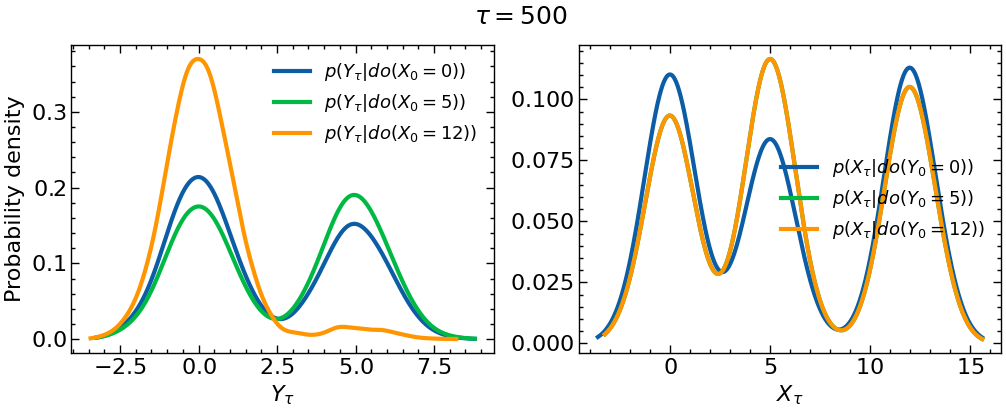

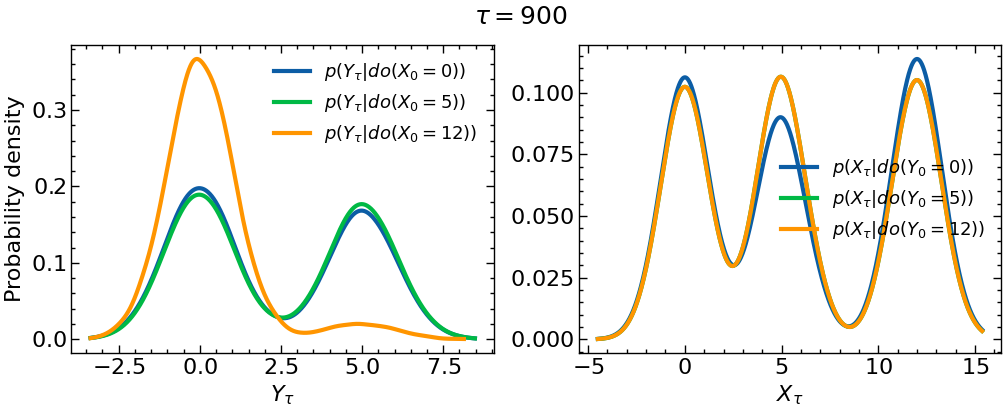

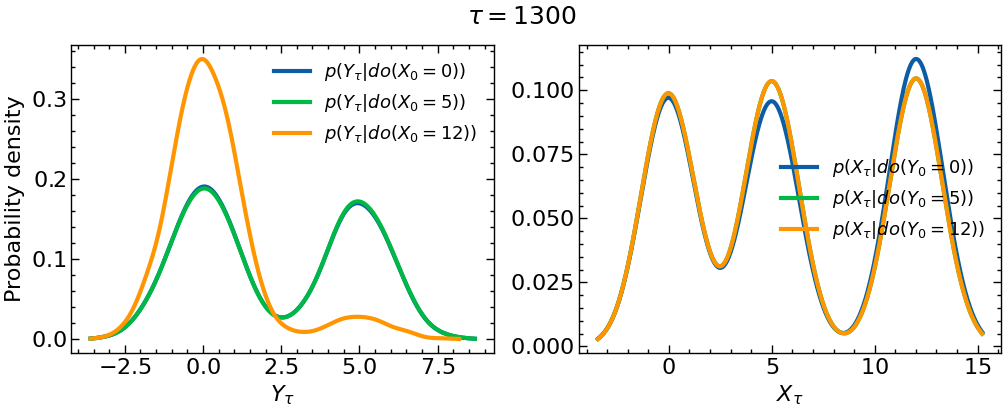

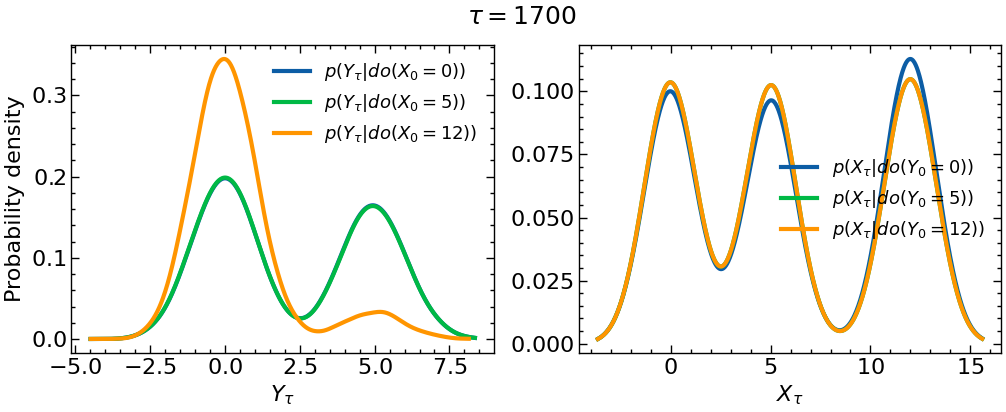

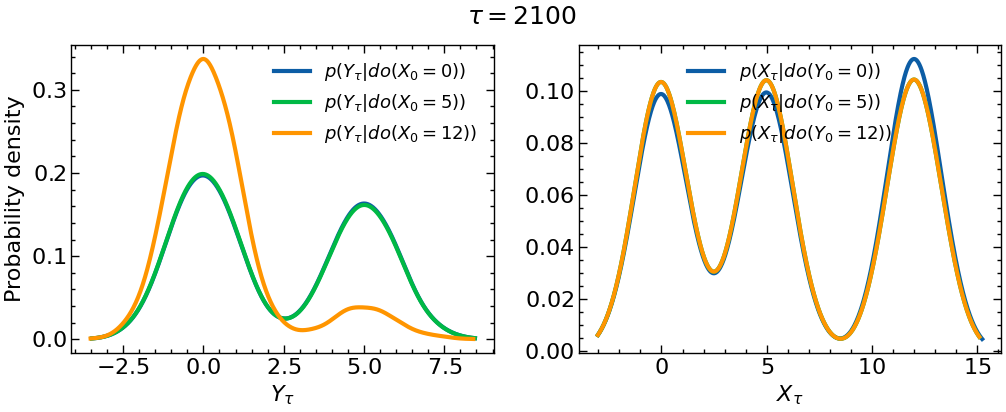

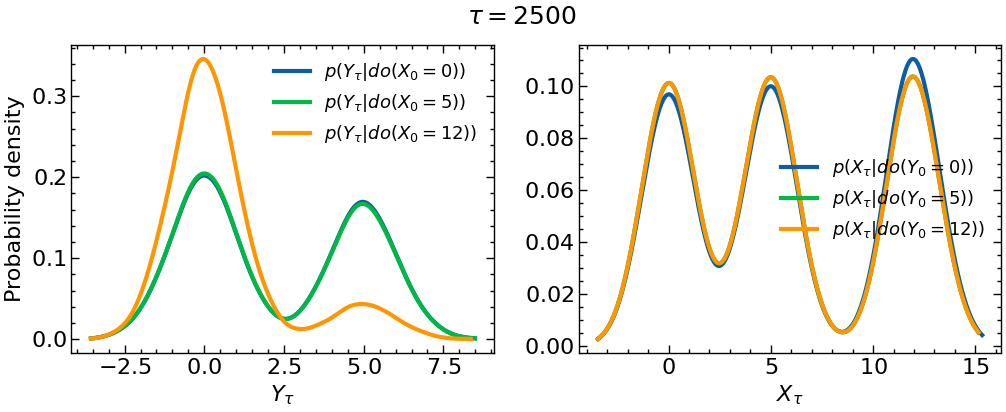

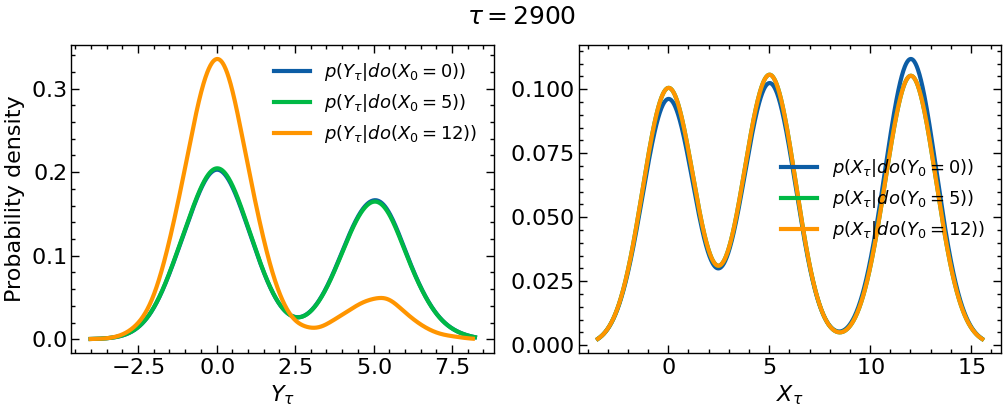

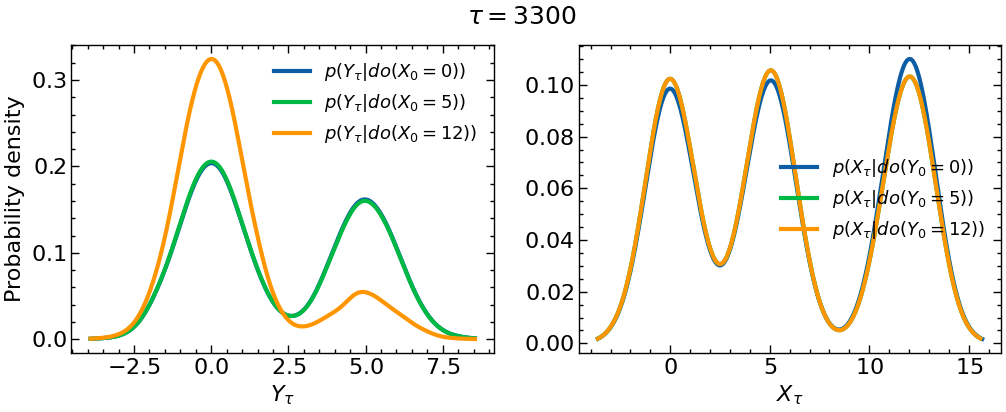

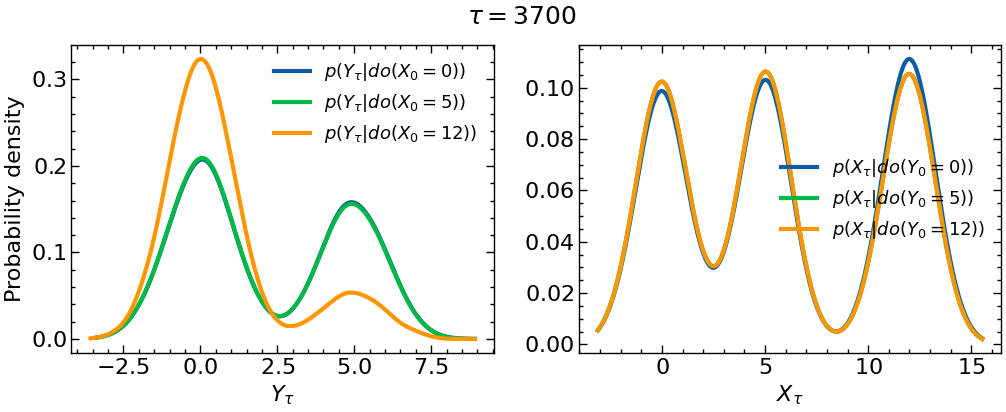

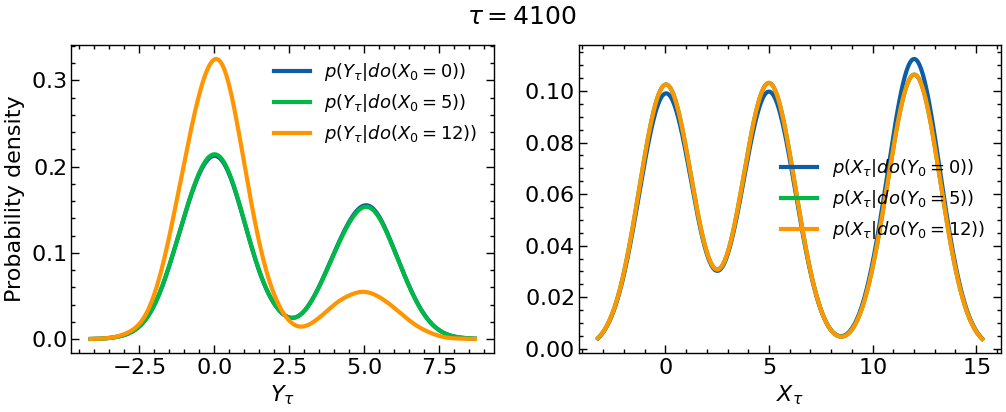

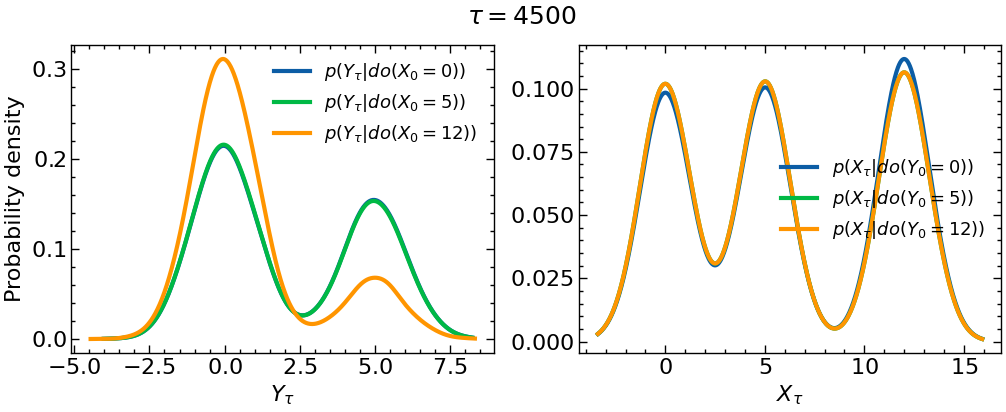

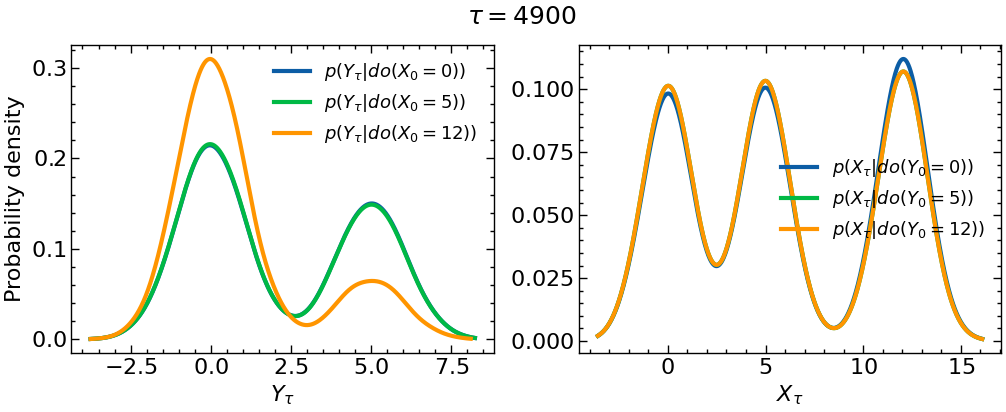

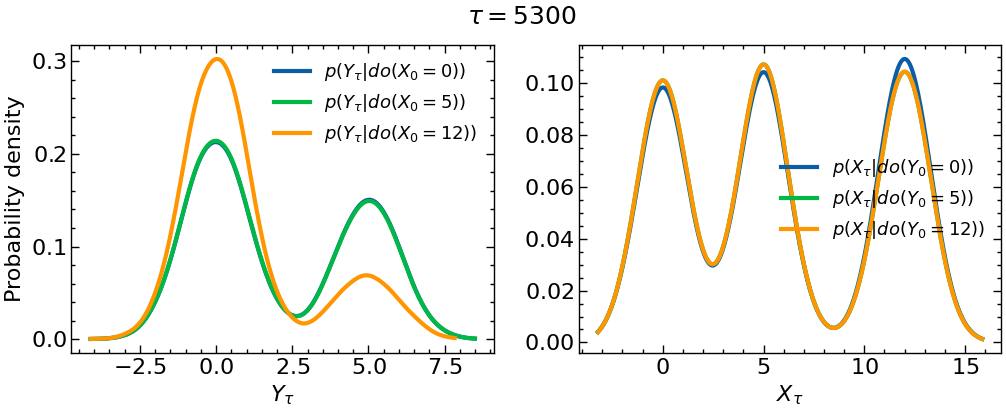

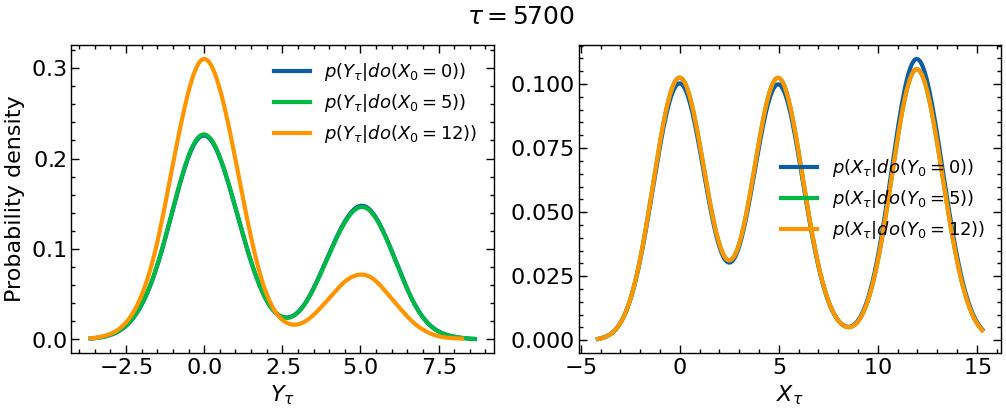

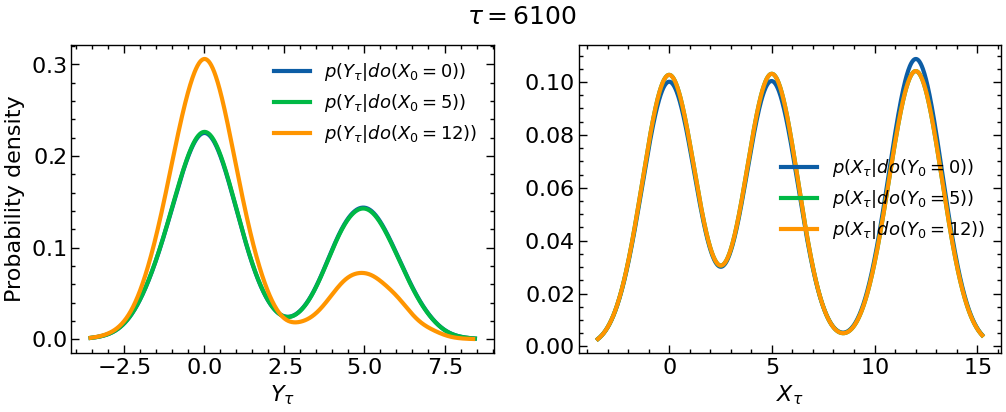

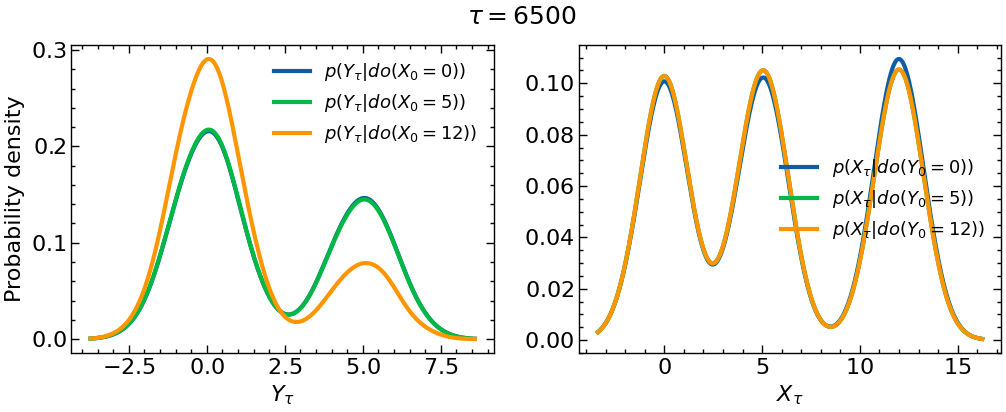

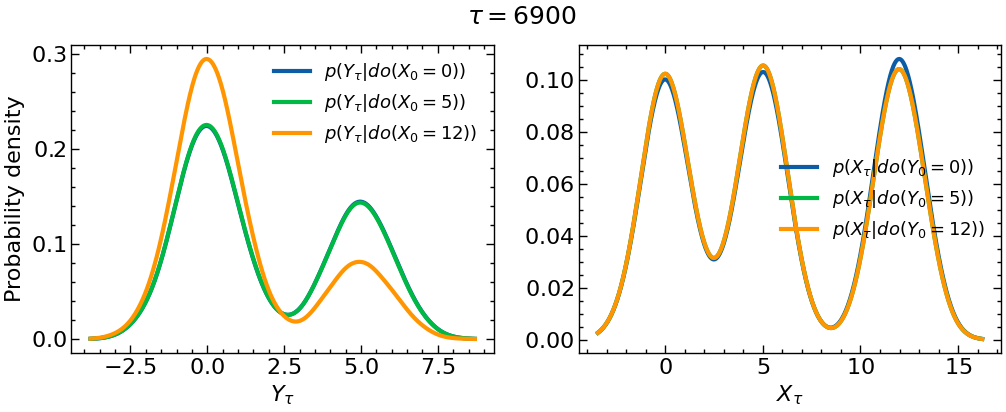

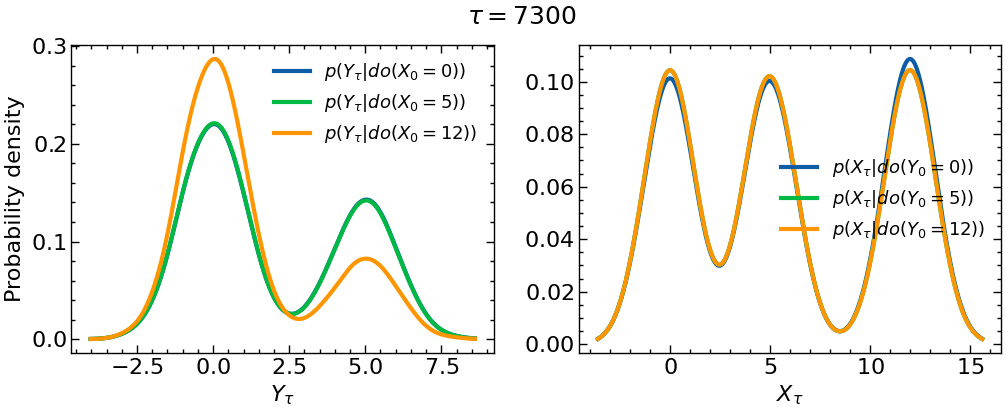

In [4]:
taus = np.append([0],np.arange(10,770,40,dtype=int))
bins = 50
linewidth = 3
alpha = 1

for itau, tau in enumerate(taus):
    fig, ax = plt.subplots(1,2,figsize=(12,4))

    #do(X=0)
    kde = gaussian_kde(traj_intx0[tau,:,1])
    x_range = np.linspace(min(traj_intx0[tau,:,1]), max(traj_intx0[tau,:,1]), 1000)
    ax[0].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(Y_{\\tau}|do(X_0=0))$")
    #do(X=5)
    kde = gaussian_kde(traj_intx5[tau,:,1])
    x_range = np.linspace(min(traj_intx5[tau,:,1]), max(traj_intx5[tau,:,1]), 1000)
    ax[0].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(Y_{\\tau}|do(X_0=5))$")
    #do(X=12)
    kde = gaussian_kde(traj_intx12[tau,:,1])
    x_range = np.linspace(min(traj_intx12[tau,:,1]), max(traj_intx12[tau,:,1]), 1000)
    ax[0].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(Y_{\\tau}|do(X_0=12))$")

    #do(Y=0)
    kde = gaussian_kde(traj_inty0[tau,:,0])
    x_range = np.linspace(min(traj_inty0[tau,:,0]), max(traj_inty0[tau,:,0]), 1000)
    ax[1].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(X_{\\tau}|do(Y_0=0))$")
    #do(Y=5)
    kde = gaussian_kde(traj_inty5[tau,:,0])
    x_range = np.linspace(min(traj_inty5[tau,:,0]), max(traj_inty5[tau,:,0]), 1000)
    ax[1].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(X_{\\tau}|do(Y_0=5))$")
    #do(Y=12)
    kde = gaussian_kde(traj_inty5[tau,:,0])
    x_range = np.linspace(min(traj_inty5[tau,:,0]), max(traj_inty5[tau,:,0]), 1000)
    ax[1].plot(x_range, kde(x_range), alpha=alpha, linewidth=linewidth, label="$p(X_{\\tau}|do(Y_0=12))$")

    #ax[0].hist(traj_intx0[tau,:,1],  alpha=alpha, bins=bins, linewidth=linewidth, label="$p(Y_{\\tau}|do(X=0))$", histtype="step", density=True)
    #ax[0].hist(traj_intx5[tau,:,1],  alpha=alpha, bins=bins, linewidth=linewidth, label="$p(Y_{\\tau}|do(X=5))$", histtype="step",density=True)
    #ax[0].hist(traj_intx12[tau,:,1], alpha=alpha, bins=bins, linewidth=linewidth, label="$p(Y_{\\tau}|do(X=12))$",histtype="step", density=True)
    #ax[1].hist(traj_inty0[tau,:,0],  alpha=alpha, bins=bins, linewidth=linewidth, label="$p(X_{\\tau}|do(Y=0))$", histtype="step",density=True)
    #ax[1].hist(traj_inty5[tau,:,0],  alpha=alpha, bins=bins, linewidth=linewidth, label="$p(X_{\\tau}|do(Y=5))$", histtype="step",density=True)
    ax[0].set(xlabel="$Y_{\\tau}$", ylabel="Probability density")
    ax[1].set(xlabel="$X_{\\tau}$")
    ax[0].legend(fontsize=13)
    ax[1].legend(fontsize=13)
    plt.suptitle(f"$\\tau = {tau*10}$", fontsize=18) # multiply by 10 to have same units used in panels E and F
    #plt.savefig(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far_int/figures/tau{tau}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

### Compute KL divergences

In [12]:
def estimate_pdf(data, points):
        kde = gaussian_kde(data)
        return kde(points)

# compute KL divergence
def kl_divergence(X, Y, num_points=1000):
    # Generate a range of values to estimate the PDFs
    min_value = min(np.min(X), np.min(Y))
    max_value = max(np.max(X), np.max(Y))
    points = np.linspace(min_value, max_value, num_points)

    # Estimate PDFs for both X and Y
    pdf_X = estimate_pdf(X, points)
    pdf_Y = estimate_pdf(Y, points)
    
    # Add a small epsilon to avoid division by zero or log(0)
    epsilon = 1e-10
    pdf_X = np.clip(pdf_X, epsilon, None)
    pdf_Y = np.clip(pdf_Y, epsilon, None)
    
    # Step 3: Compute KL divergence
    kl_div = np.sum(pdf_X * np.log(pdf_X / pdf_Y)) * (max_value - min_value) / num_points
    return kl_div

In [13]:
KLs_x0_x5 = []
KLs_x0_x12 = []
KLs_x5_x12 = []
KLs_y0_y5 = []

for itau, tau in tqdm(enumerate(taus)):
    # KL[p(Y|do(X=0)) || p(Y|do(X=5))]
    KLs_x0_x5.append(kl_divergence(traj_intx0[tau,:,1],traj_intx5[tau,:,1]))

    # KL[p(Y|do(X=0)) || p(Y|do(X=12))]
    KLs_x0_x12.append(kl_divergence(traj_intx0[tau,:,1],traj_intx12[tau,:,1]))

    # KL[p(Y|do(X=0)) || p(Y|do(X=12))]
    KLs_x5_x12.append(kl_divergence(traj_intx5[tau,:,1],traj_intx12[tau,:,1]))

    # KL[p(X|do(Y=0)) || p(X|do(Y=5))]
    KLs_y0_y5.append(kl_divergence(traj_inty0[tau,:,1],traj_inty5[tau,:,1]))

    # KL[p(X|do(Y=0)) || p(X|do(Y=12))]
    KLs_y0_y12.append(kl_divergence(traj_inty0[tau,:,1],traj_inty12[tau,:,1]))

    # KL[p(X|do(Y=5)) || p(X|do(Y=12))]
    KLs_y5_y12.append(kl_divergence(traj_inty5[tau,:,1],traj_inty5[tau,:,1]))

with open("","wb") as file:
    pickle.dump([KLs_x0_x5,KLs_x0_x12,KLs_x5_x12,KLs_y0_y5,KLs_y0_y12,KLs_x0_x5],file)

SyntaxError: invalid syntax (1444963355.py, line 26)

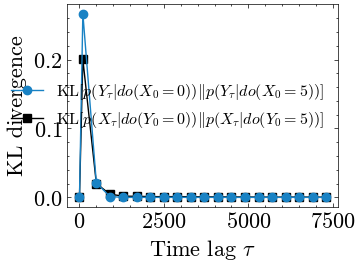

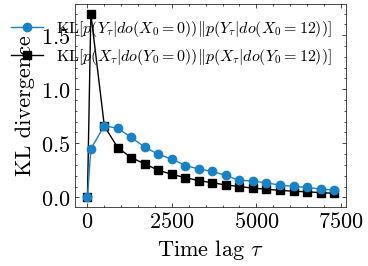

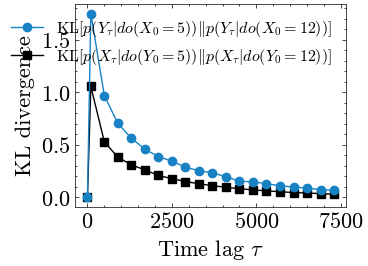

In [ ]:
with open("/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far_int/pickles_plot/KL_divergences.p","rb") as file:
    KLs_x0_x5, KLs_x0_x12, KLs_x5_x12, KLs_y0_y5, KLs_y0_y12, KLs_y5_y12 = pickle.load(file)

taus = np.append([0],np.arange(10,770,40,dtype=int))
bins = 50
linewidth = 1
alpha = 1

# do(0) vs do(5)
#plt.figure(figsize=(5,3.5))
plt.plot(10*taus, np.append([0],KLs_x0_x5),  'o-',  color=colors[0], label="KL$[p(Y_\\tau|do(X_0=0)) \| p(Y_\\tau|do(X_0=5))]$", zorder=1)
plt.plot(10*taus, np.append([0],KLs_y0_y5),  's-',  color=colors[1], label="KL$[p(X_\\tau|do(Y_0=0)) \| p(X_\\tau|do(Y_0=5))]$", zorder=0)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("KL divergence")
plt.legend(fontsize=11.5, loc=(0.1,1.05))
#plt.suptitle(f"$\\tau = {tau*10}$", fontsize=18) # multiply by 10 to have same units used in panels E and F
#plt.savefig(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far_int/figures/KL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# do(0) vs do(12)
#plt.figure(figsize=(5,3.5))
plt.plot(10*taus, np.append([0],KLs_x0_x12),  'o-',  color=colors[0], label="KL$[p(Y_\\tau|do(X_0=0)) \| p(Y_\\tau|do(X_0=12))]$", zorder=1)
plt.plot(10*taus, np.append([0],KLs_y0_y12),  's-',  color=colors[1], label="KL$[p(X_\\tau|do(Y_0=0)) \| p(X_\\tau|do(Y_0=12))]$", zorder=0)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("KL divergence")
plt.legend(fontsize=11.5)
#plt.suptitle(f"$\\tau = {tau*10}$", fontsize=18) # multiply by 10 to have same units used in panels E and F
#plt.savefig(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far_int/figures/KL.pdf", dpi=300, bbox_inches="tight")
plt.show()

# do(5) vs do(12)
#plt.figure(figsize=(5,3.5))
plt.plot(10*taus, np.append([0],KLs_x5_x12),  'o-',  color=colors[0], label="KL$[p(Y_\\tau|do(X_0=5)) \| p(Y_\\tau|do(X_0=12))]$", zorder=1)
plt.plot(10*taus, np.append([0],KLs_y5_y12),  's-',  color=colors[1], label="KL$[p(X_\\tau|do(Y_0=5)) \| p(X_\\tau|do(Y_0=12))]$", zorder=0)
plt.xlabel("Time lag $\\tau$")
plt.ylabel("KL divergence")
plt.legend(fontsize=11.5)
#plt.suptitle(f"$\\tau = {tau*10}$", fontsize=18) # multiply by 10 to have same units used in panels E and F
#plt.savefig(f"/scratch/vdeltatt/imbalance-gain-causality/langevin/asymmetric_energy_far_int/figures/KL.pdf", dpi=300, bbox_inches="tight")
plt.show()